In [7]:
from src.utils import get_data_env
from src.dataloading import EpiConfig, DataOrchestrator

In [8]:
# get data
disease_name    = 'influenza'
nuts_level      = 'nuts3'
min_date        = '2011-06-15'
max_date        = '2020-06-01'
split_trainval  = '2018-06-01'
split_valtest   = '2019-06-01'
split_berlin    = False

horizon_size    = 1
horizon_leadtime= 3
sequence_length = 1
lag_num         = 3

config = EpiConfig(
    disease             = disease_name,
    data_env_dir        = get_data_env(),
    date_range          = (min_date, max_date),
    horizon_size        = horizon_size,
    sequence_length     = sequence_length,
    horizon_leadtime    = horizon_leadtime,
    lag_num             = lag_num,
    nuts_level          = nuts_level,
    log_transform       = ['incidence'],
    split_berlin        = split_berlin,
    include_population  = True,
    split_trainval      = split_trainval, 
    split_valtest       = split_valtest,
    target_column       = 'incidence',
    lag_column          = 'incidence',  
    verbose             = 0  
    )    

data_orchestrator = (DataOrchestrator(config)
                        .load_raw()
                        .harmonize_raw()
                        .process_data()
                        .build_features()
                        .normalize()
                        .finalize()
                        )

In [9]:
from src.dataloading import ShallowDataLoaderManager, BaseLineDataLoaderManager
from src.models import PersistenceModel, ClimateologyModel, ClimaScaleModel

shallow_data = ShallowDataLoaderManager(data_orchestrator).construct_dataloaders()
baseline_data= BaseLineDataLoaderManager(data_orchestrator)

persistence = PersistenceModel(baseline_data)
climateology= ClimateologyModel(baseline_data)
climascale  = ClimaScaleModel(baseline_data)

persistence.forecast('test')
climateology.forecast('test')
climascale.forecast('test')

ClimaScaleModel(name='climascale_model')

In [10]:
from src.models import NodeRFModel

rf = NodeRFModel(shallow_data, verbose = -1)
rf.set_global_hparams()
rf.set_model_hparams()
rf.train()
rf.forecast('test')


NodeRFModel(name='noderfmodel')

In [11]:
from src.evaluation import Evaluator

evaluation = Evaluator([persistence,climateology, climascale,rf]).add_evaluation()

computing metrics:   0%|                                                                                | 0/6 [00:00<?, ?it/s]

computing metrics: 100%|████████████████████████████████████████████████████████████████████████| 6/6 [00:03<00:00,  1.55it/s]


/scratch/de-schrijvers/projects/infectious_disease_gnn/src/evaluation/evaluationplotter.py:215: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='center', fontsize=8)
/scratch/de-schrijvers/projects/infectious_disease_gnn/src/evaluation/evaluationplotter.py:215: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='center', fontsize=8)
/scratch/de-schrijvers/projects/infectious_disease_gnn/src/evaluation/evaluationplotter.py:215: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='center', fontsize=8)
/scratch/de-schrijvers/projects/infectious_disease_gnn/src/evaluation/evaluationplott

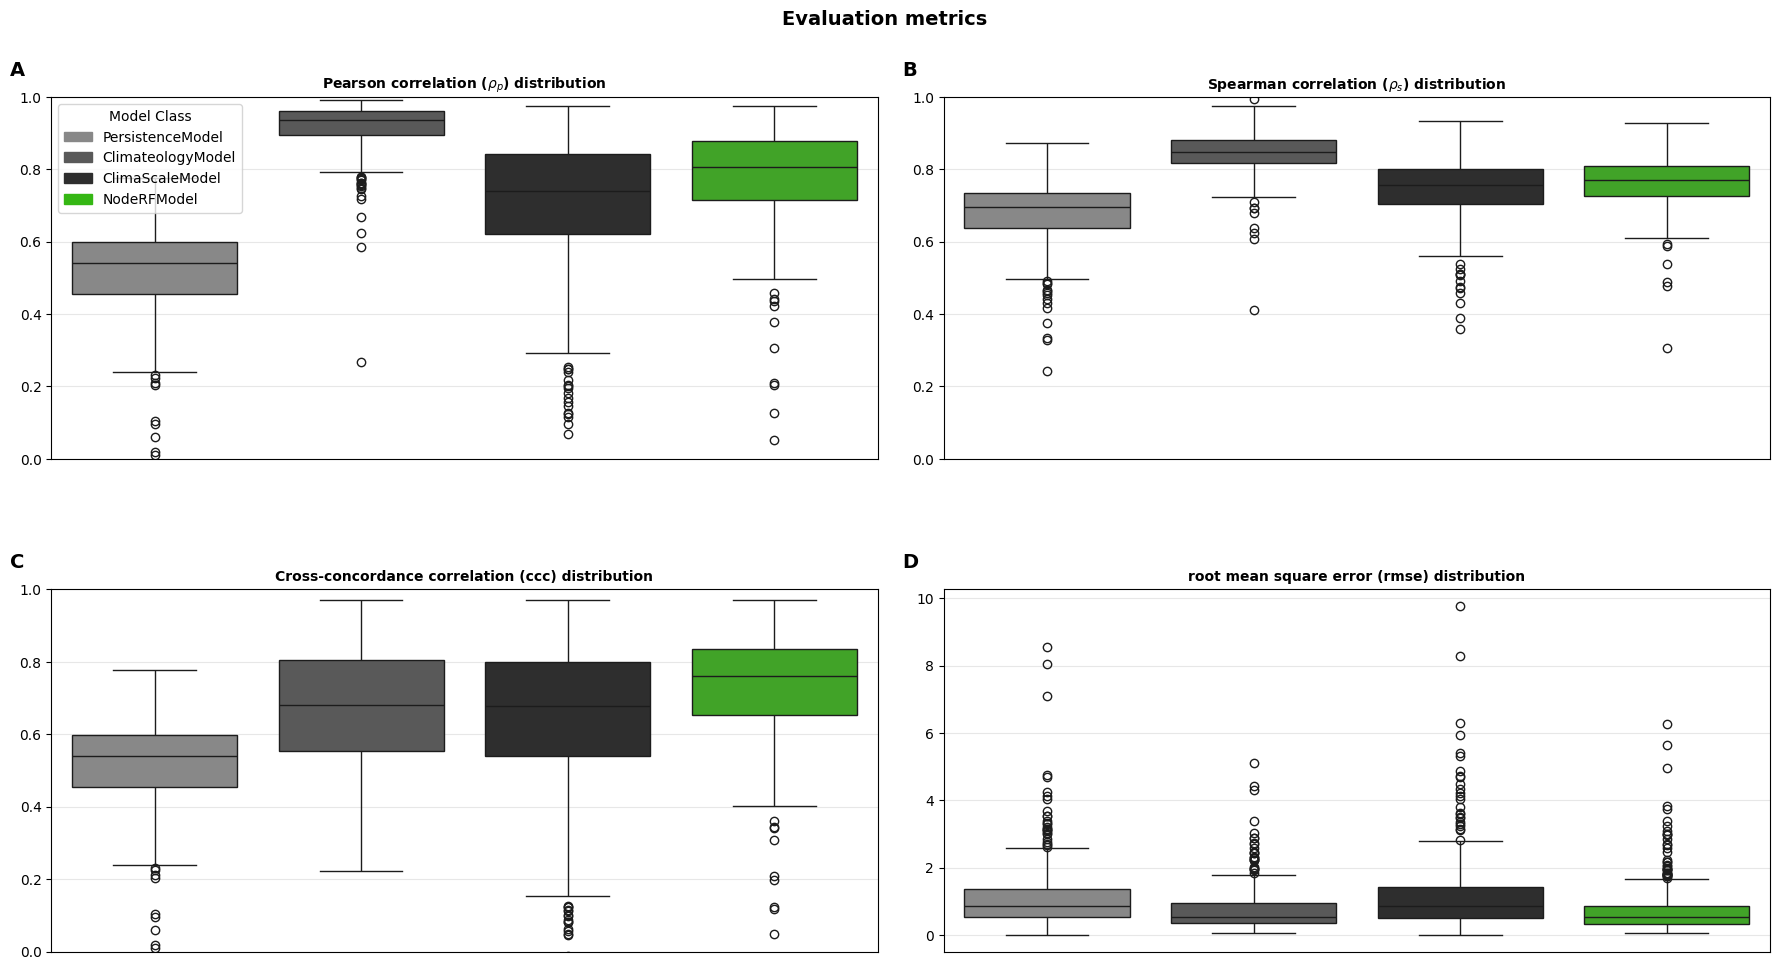

In [12]:

f_merged_raw    = evaluation.plotter.plot_metric_compilation(subfig_size = (9,5));

f_merged = (f_merged_raw
    .labels.change_suptitle(suptitle='Evaluation metrics', fontsize = 14, fontweight = 'bold')
    .labels.set_suptitle_y(y=1.05)
    .labels.change_title('Pearson correlation ($\\rho_{p}$) distribution', fontweight = 'bold',     ax = 0)
    .labels.change_title('Spearman correlation ($\\rho_s$) distribution',  fontweight = 'bold',     ax = 1)
    .labels.change_title('Cross-concordance correlation (ccc) distribution', fontweight = 'bold',   ax = 2)    
    .labels.change_title('root mean square error (rmse) distribution', fontweight = 'bold',         ax = 3)    
    .labels.change_ylab('')
    .labels.change_xlab("")
    .ticks.change_xticks([])
    .layout.set_ylim([0,1],ax = 0)
    .layout.set_ylim([0,1],ax = 1)
    .layout.set_ylim([0,1],ax = 2)        
    .labels.set_tag('A', y = 1.1, ax = 0)   
    .labels.set_tag('B', y = 1.1, ax = 1) 
    .labels.set_tag('C', y = 1.1, ax = 2) 
    .labels.set_tag('D', y = 1.1, ax = 3)      
    .legend.move('upper left', ax = 0)             
    )
f_merged.show()

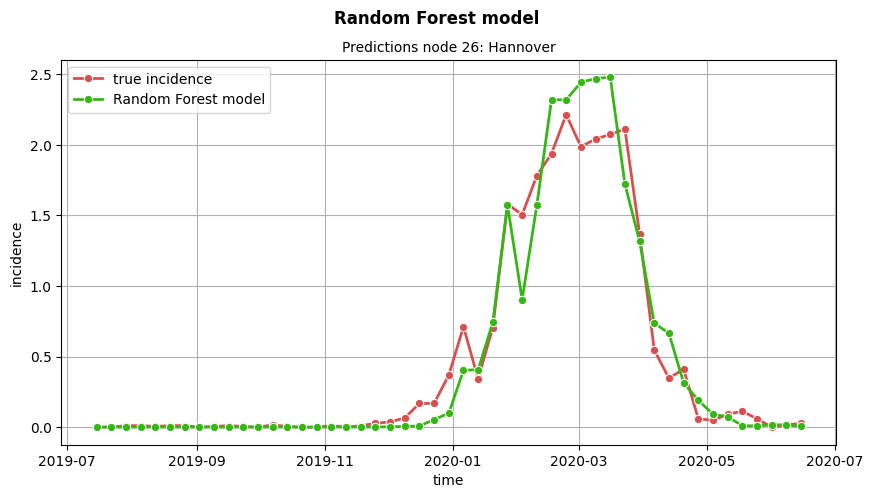

In [18]:
raw_f1 = rf.show_forecasts(15)

f1 = (raw_f1
      .labels.change_suptitle('Random Forest model','bold',12)
      .labels.change_title('Predictions node 26: Hannover')
      .labels.change_xlab('time')
      .labels.change_ylab('incidence')
      .legend.set_labels(['true incidence','Random Forest model'])
      .change_figsize(10,5).legend.move('upper left'))

f1.show()